
# Module 24: Principal Component Analysis (PCA)

This notebook is a **practice-only notebook** for students.

### Instructions for Students
- Complete every **TODO** step by step.
- Run the cells after completing each TODO.
- Focus on *why* you are doing each step, not just *how*.

### Dataset Used
We use the **Breast Cancer Wisconsin dataset**, which is:
- Numeric
- Medium dimensional (30 features)
- Very suitable for PCA
- Common in real ML pipelines



## 1) Imports (Given)


In [11]:
#Given for you
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


## 2) Load the Dataset (TODO)

TODO:
- Load the breast cancer dataset using sklearn
- Create:
  - X: feature DataFrame
  - y: target Series
- Print the shape of X and y


In [12]:
# TODO: Load dataset
data = load_breast_cancer()
x = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='class')
x.shape, y.shape
x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



## 3) Inspect Feature Scales (TODO)


In [13]:
# TODO: Inspect feature statistics
x.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
mean radius,14.127292,3.524049,6.981000,28.11000
mean texture,19.289649,4.301036,9.710000,39.28000
mean perimeter,91.969033,24.298981,43.790000,188.50000
mean area,654.889104,351.914129,143.500000,2501.00000
mean smoothness,0.096360,0.014064,0.052630,0.16340
mean compactness,0.104341,0.052813,0.019380,0.34540
mean concavity,0.088799,0.079720,0.000000,0.42680
mean concave points,0.048919,0.038803,0.000000,0.20120
mean symmetry,0.181162,0.027414,0.106000,0.30400
mean fractal dimension,0.062798,0.007060,0.049960,0.09744



## 4) Scale the Features (TODO)


In [14]:
# TODO: Scale features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]])


## 5) Fit PCA Without Limiting Components (TODO)


In [19]:
# TODO: Fit full PCA and compute explained variance
pca = PCA()

x_pca = pca.fit_transform(x_scaled)
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

explained[:10]

array([0.44272026, 0.18971182, 0.09393163, 0.06602135, 0.05495768,
       0.04024522, 0.02250734, 0.01588724, 0.01389649, 0.01168978])


## 6) Explained Variance Plot (TODO)


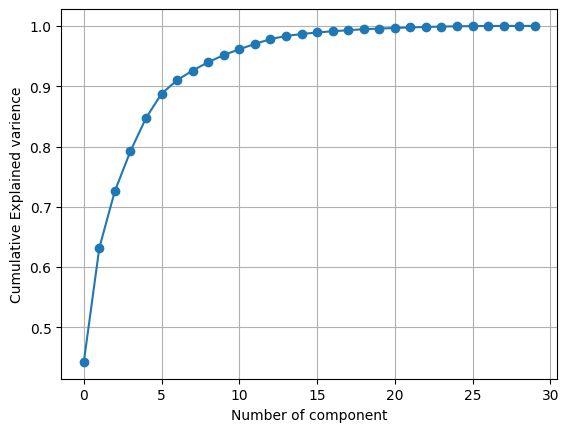

In [23]:
# TODO: Plot cumulative explained variance
plt.figure()
plt.plot(cum_explained, marker='o')
plt.xlabel('Number of component')
plt.ylabel('Cumulative Explained varience')
plt.grid()
plt.show()


## 7) Choose Number of Components (TODO)


In [25]:
# TODO: Find k90 and k95 and k97
k95 = int(np.argmax(cum_explained>=.95) +1)
k95

10


## 8) Apply PCA with Chosen Components (TODO)


In [26]:
# TODO: Apply PCA with selected number of components
pca = PCA(n_components=k95)
x_pca = pca.fit_transform(x_scaled)

x_pca.shape

(569, 10)


## 9) Inspect Principal Components (TODO)


In [30]:
# TODO: Inspect PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index = x.columns,
    columns = [f'pc{i}' for i in range(k95)]
)

loadings.head(10)

,pc0,pc1,pc2,pc3,pc4,pc5,pc6,pc7,pc8,pc9
mean radius,0.218902,-0.233857,-0.008531,-0.041409,-0.037786,0.018741,-0.124088,-0.007452,-0.223110,0.095486
mean texture,0.103725,-0.059706,0.064550,0.603050,0.049469,-0.032179,0.011400,0.130675,0.112699,0.240934
mean perimeter,0.227537,-0.215181,-0.009314,-0.041983,-0.037375,0.017308,-0.114477,-0.018687,-0.223739,0.086386
mean area,0.220995,-0.231077,0.028700,-0.053434,-0.010331,-0.001888,-0.051653,0.034674,-0.195586,0.074956
mean smoothness,0.142590,0.186113,-0.104292,-0.159383,0.365089,-0.286374,-0.140669,-0.288975,0.006425,-0.069293
mean compactness,0.239285,0.151892,-0.074092,-0.031795,-0.011704,-0.014131,0.030918,-0.151396,-0.167841,0.012936
mean concavity,0.258400,0.060165,0.002734,-0.019123,-0.086375,-0.009344,-0.107520,-0.072827,0.040591,-0.135602
mean concave points,0.260854,-0.034768,-0.025564,-0.065336,0.043861,-0.052050,-0.150482,-0.152322,-0.111971,0.008055
mean symmetry,0.138167,0.190349,-0.040240,-0.067125,0.305941,0.356458,-0.093891,-0.231531,0.256040,0.572069
mean fractal dimension,0.064363,0.366575,-0.022574,-0.048587,0.044424,-0.119431,0.295760,-0.177121,-0.123741,0.081103



## 10) Visualize Data Using First Two Principal Components (TODO)


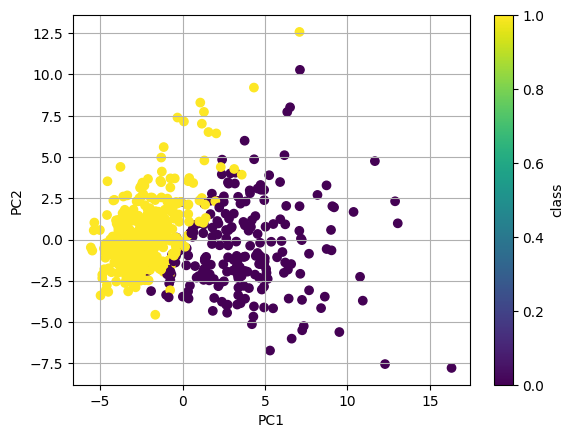

In [32]:
# TODO: 2D PCA visualization
pca2 = PCA(n_components=2)
x_2d = pca2.fit_transform(x_scaled)

plt.figure()
scatter = plt.scatter(x_2d[:,0], x_2d[:,1], c=y, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.colorbar(scatter, label='class')
plt.show()


## 11) PCA in a Model Pipeline (TODO)


In [38]:
# TODO: Model comparison with and without PCA
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.25, stratify=y, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=500))
])

pipe.fit(x_train, y_train)
pred = pipe.predict(x_test)
acc = accuracy_score(y_test, pred)
print('Accuracy: ',acc)



pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=.95)),
    ('clf', LogisticRegression(max_iter=500))
])

pipe_pca.fit(x_train, y_train)
pred_pca = pipe_pca.predict(x_test)
acc_pca = accuracy_score(y_test, pred_pca)
print('Accuracy PCA: ',acc_pca)

data = {
    'Without PCA' : [acc],
    'With PCA': [acc_pca]
}

df = pd.DataFrame(data)
df


Accuracy:  0.986013986013986
Accuracy PCA:  0.9790209790209791


,Without PCA,With PCA
0,0.986014,0.979021



## 12) Reflection Questions

Answer briefly in markdown:
1. Did PCA reduce the number of features significantly?
2. Did PCA improve, reduce, or maintain accuracy?
3. Would you use PCA for this dataset in a real project? Why or why not?
